In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [4]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv("../data/raw/heart_disease_data.csv")

X = df.drop("target",axis=1)

y = df["target"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

In [8]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

In [9]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True,random_state=42))
])

In [10]:
tree_pipeline = Pipeline([
    ("model",
     DecisionTreeClassifier(random_state=42))
])

In [11]:
forest_pipeline = Pipeline([
    ("model",
     RandomForestClassifier(random_state=42))
])

In [12]:
models = {

    "Logistic Regression": logistic_pipeline,

    "KNN": knn_pipeline,

    "SVM": svm_pipeline,

    "Decision Tree": tree_pipeline,

    "Random Forest": forest_pipeline

}

In [13]:
results = []

In [14]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test,y_prob)
    else:
        roc = np.nan

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test,y_pred),

        "Precision": precision_score(y_test,y_pred),

        "Recall": recall_score(y_test,y_pred),

        "F1 Score": f1_score(y_test,y_pred),

        "ROC AUC": roc

    })

/Users/ashok/Documents/notebooks/Heart Disease Prediction/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [15]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333,0.869048
1,KNN,0.803279,0.769231,0.909091,0.833333,0.863095
2,SVM,0.819672,0.775000,0.939394,0.849315,0.883117
3,Decision Tree,0.704918,0.702703,0.787879,0.742857,0.697511
4,Random Forest,0.836066,0.780488,0.969697,0.864865,0.914502


In [16]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Random Forest,0.836066,0.780488,0.969697,0.864865,0.914502
2,SVM,0.819672,0.775000,0.939394,0.849315,0.883117
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333,0.869048
1,KNN,0.803279,0.769231,0.909091,0.833333,0.863095
3,Decision Tree,0.704918,0.702703,0.787879,0.742857,0.697511


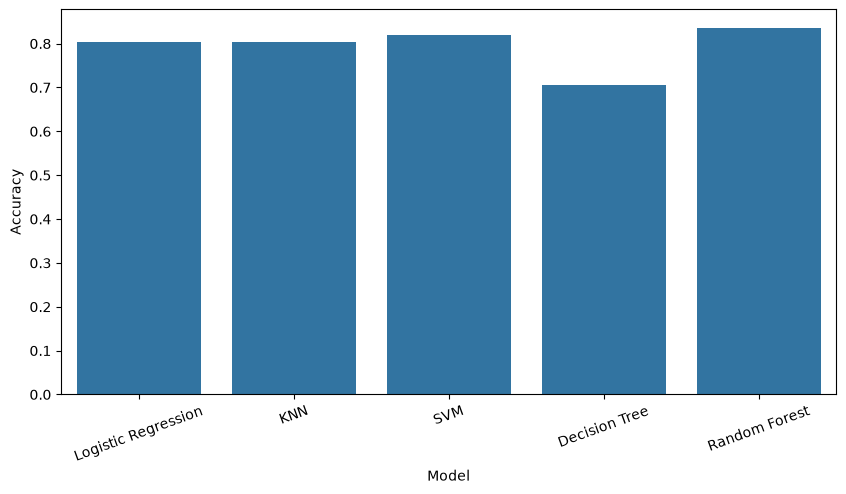

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)

plt.show()

> Random Forest achieved the highest F1-score while maintaining strong recall, suggesting it balances false positives and false negatives effectively. Logistic Regression remained competitive despite its simplicity, making it a strong baseline. Decision Tree performed less consistently, indicating possible overfitting.

| Model               | Advantages                      | Disadvantages                                |
| ------------------- | ------------------------------- | -------------------------------------------- |
| Logistic Regression | Fast, interpretable             | Assumes linear relationship                  |
| KNN                 | Simple, non-parametric          | Slow on large datasets, sensitive to scaling |
| SVM                 | Powerful for complex boundaries | Computationally expensive                    |
| Decision Tree       | Easy to explain                 | Can overfit                                  |
| Random Forest       | Robust, accurate                | Less interpretable                           |


In [18]:
from sklearn.model_selection import cross_val_score

In [19]:
scores = cross_val_score(
    forest_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)

[0.8358209  0.89230769 0.84848485 0.86153846 0.82857143]


In [20]:
print(scores.mean())
print(scores.std())

0.8533446652849639
0.02249297381452708


In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
param_grid = {

    "model__n_estimators": [50,100,200],

    "model__max_depth": [3,5,10,None],

    "model__min_samples_split": [2,5,10],

    "model__min_samples_leaf": [1,2,4]

}

In [23]:
grid = GridSearchCV(

    estimator=forest_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

In [24]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [25]:
grid.best_params_

{'model__max_depth': 3,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2,
 'model__n_estimators': 50}

In [26]:
grid.best_score_

np.float64(0.8726966756852527)

In [27]:
best_model = grid.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4


In [28]:
y_pred = best_model.predict(X_test)

In [29]:
# tuned model metrics
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

accuracy_t = accuracy_score(y_test, y_pred)
precision_t = precision_score(y_test, y_pred)
recall_t = recall_score(y_test, y_pred)
f1_t = f1_score(y_test, y_pred)
roc_t = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

# baseline (from earlier results_df)
baseline = results_df.loc[results_df["Model"] == "Random Forest"].iloc[0]

comparison_df = pd.DataFrame(
    [
        baseline[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].values,
        [accuracy_t, precision_t, recall_t, f1_t, roc_t]
    ],
    index=["Baseline", "Tuned"],
    columns=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
).round(3)

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Baseline,0.836,0.78,0.97,0.865,0.915
Tuned,0.836,0.78,0.97,0.865,0.921


In [ ]:
import joblib


joblib.dump(best_model, '../models/best_model.pkl')
print("Model saved successfully!")

Model saved successfully!
